<a href="https://colab.research.google.com/github/Saumya1295/Summer-Internship-Training/blob/main/Election_sentiments_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import Counter

In [ ]:
rahul = pd.read_csv("C:/Users/saumy/Downloads/rahul_reviews.csv")
modi = pd.read_csv("C:/Users/saumy/Downloads/modi_reviews.csv")

In [ ]:
rahul.head()

,Unnamed: 0,User,Tweet
0,0,Sunnysweet16,Wonder why no academic or journalist asks INC ...
1,1,drnitinchaube,Congrats for the change #australiavotes2019 an...
2,2,mrvivek07,Peopel Say “Govt Ne 70 Years Kya kiya”.\nUnse ...
3,3,JosephPravinP,"@ajaymaken @RahulGandhi And as a final touch, ..."
4,4,VandanaMegastar,#LokSabhaElections2019 Anyone not having mass ...


In [ ]:
modi.head()

,Unnamed: 0,User,Tweet
0,0,advosushildixit,@anjanaomkashyap I am seeing you as future #bj...
1,1,jiaeur,#LokSabhaElections2019 \n23rd May 2019 will re...
2,2,PVenkatGandhi,#LokSabhaElections2019 \n23rd May 2019 will re...
3,3,TheNirbhay1,PM Modi creates a new record of being the only...
4,4,ShakeChilli,@abhijitmajumder Appointment of Successor! \n\...


In [ ]:
print("Rahul Dataset Shape:", rahul.shape)
print("Modi Dataset Shape:", modi.shape)

Rahul Dataset Shape: (14261, 3)
Modi Dataset Shape: (25688, 3)


In [ ]:
rahul.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14261 entries, 0 to 14260
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  14261 non-null  int64 
 1   User        14261 non-null  object
 2   Tweet       14261 non-null  object
dtypes: int64(1), object(2)
memory usage: 334.4+ KB


In [ ]:
modi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25688 entries, 0 to 25687
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  25688 non-null  int64 
 1   User        25683 non-null  object
 2   Tweet       25683 non-null  object
dtypes: int64(1), object(2)
memory usage: 602.2+ KB


In [ ]:
print(rahul.columns)
print(modi.columns)

Index(['Unnamed: 0', 'User', 'Tweet'], dtype='object')
Index(['Unnamed: 0', 'User', 'Tweet'], dtype='object')


In [ ]:
print(rahul.isnull().sum())

Unnamed: 0    0
User          0
Tweet         0
dtype: int64


In [ ]:
print(modi.isnull().sum())

Unnamed: 0    0
User          5
Tweet         5
dtype: int64


In [ ]:
print("Rahul Duplicate Rows:", rahul.duplicated().sum())
print("Modi Duplicate Rows:", modi.duplicated().sum())

Rahul Duplicate Rows: 0
Modi Duplicate Rows: 0


In [ ]:
rahul.drop_duplicates(inplace=True)
modi.drop_duplicates(inplace=True)

In [ ]:
rahul.drop("Unnamed: 0", axis=1, inplace=True)
modi.drop("Unnamed: 0", axis=1, inplace=True)

In [ ]:
print("Unique Rahul Users:", rahul['User'].nunique())
print("Unique Modi Users:", modi['User'].nunique())

Unique Rahul Users: 7865
Unique Modi Users: 14116


In [ ]:
print("Rahul Tweets:", len(rahul))
print("Modi Tweets:", len(modi))

Rahul Tweets: 14261
Modi Tweets: 25688


In [ ]:
rahul['tweet_length'] = rahul['Tweet'].astype(str).apply(len)
modi['tweet_length'] = modi['Tweet'].astype(str).apply(len)

print("Average Rahul Tweet Length:",
      rahul['tweet_length'].mean())

print("Average Modi Tweet Length:",
      modi['tweet_length'].mean())

Average Rahul Tweet Length: 217.90891241848396
Average Modi Tweet Length: 219.6437246963563


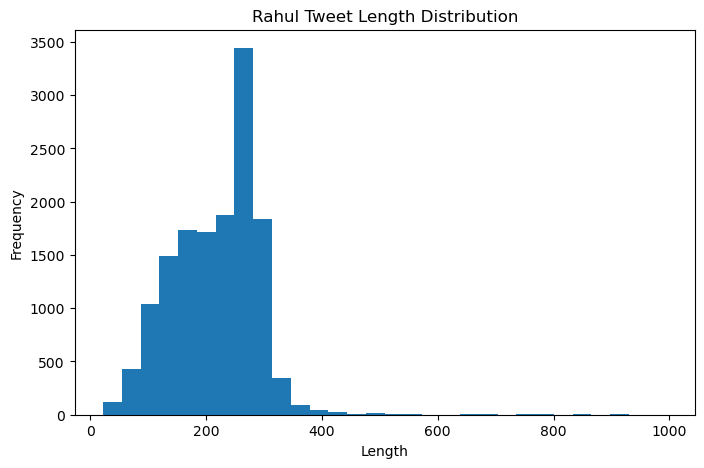

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(rahul['tweet_length'], bins=30)
plt.title("Rahul Tweet Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

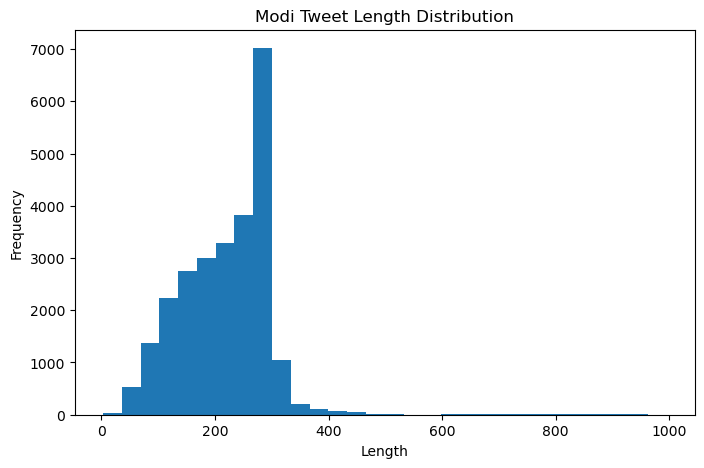

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(modi['tweet_length'], bins=30)
plt.title("Modi Tweet Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

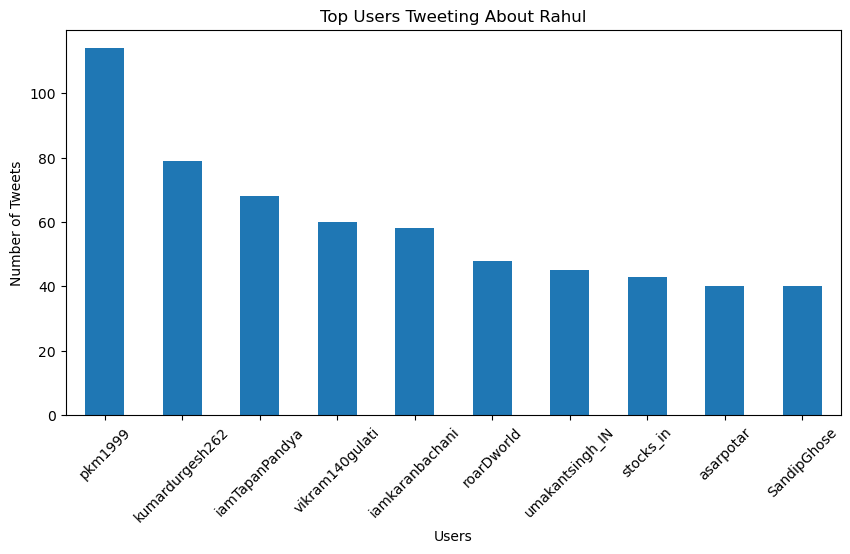

In [ ]:
top_users = rahul['User'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_users.plot(kind='bar')

plt.title("Top Users Tweeting About Rahul")
plt.xlabel("Users")
plt.ylabel("Number of Tweets")

plt.xticks(rotation=45)
plt.show()

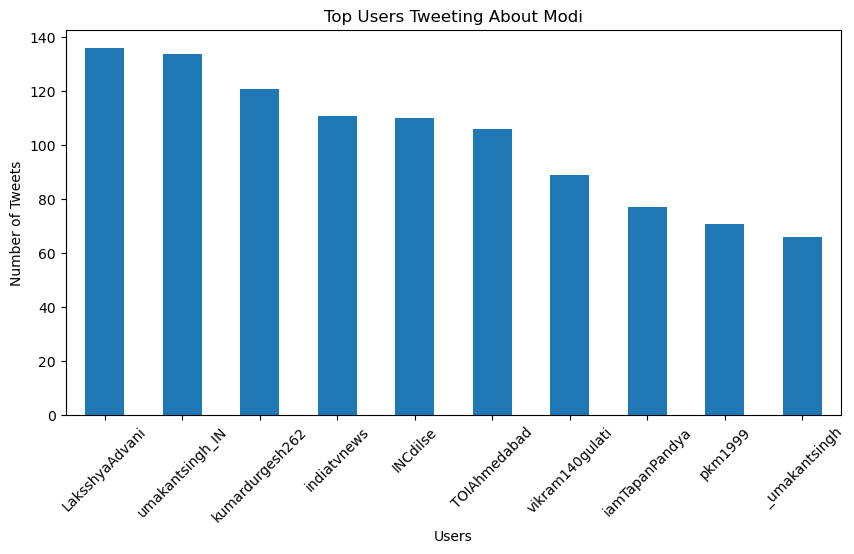

In [ ]:
top_users = modi['User'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_users.plot(kind='bar')

plt.title("Top Users Tweeting About Modi")
plt.xlabel("Users")
plt.ylabel("Number of Tweets")

plt.xticks(rotation=45)
plt.show()

In [ ]:
rahul['clean_tweet'] = rahul['Tweet'].str.lower()
modi['clean_tweet'] = modi['Tweet'].str.lower()

In [ ]:
def clean_text(text):
    text = re.sub(r"http\S+", "", str(text))
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text.lower()

rahul['clean_tweet'] = rahul['Tweet'].apply(clean_text)
modi['clean_tweet'] = modi['Tweet'].apply(clean_text)

In [ ]:
rahul_words = " ".join(rahul['clean_tweet']).split()

common_words = Counter(rahul_words).most_common(20)

print(common_words)

[('to', 9898), ('the', 9406), ('of', 7586), ('is', 7259), ('in', 6750), ('and', 6011), ('loksabhaelections', 5499), ('rahulgandhi', 5100), ('a', 5059), ('for', 5041), ('you', 4219), ('bjp', 4134), ('gandhi', 3397), ('congress', 3311), ('will', 3281), ('rahul', 3171), ('this', 2705), ('on', 2679), ('he', 2567), ('that', 2444)]


In [ ]:
modi_words = " ".join(modi['clean_tweet']).split()

common_words = Counter(modi_words).most_common(20)

print(common_words)

[('to', 18406), ('the', 18209), ('of', 14822), ('in', 13148), ('is', 12464), ('and', 11407), ('for', 10719), ('modi', 10518), ('loksabhaelections', 10509), ('bjp', 10309), ('a', 9208), ('pm', 8131), ('you', 6411), ('narendramodi', 5786), ('will', 5742), ('india', 4898), ('on', 4792), ('i', 4722), ('this', 4678), ('not', 4450)]


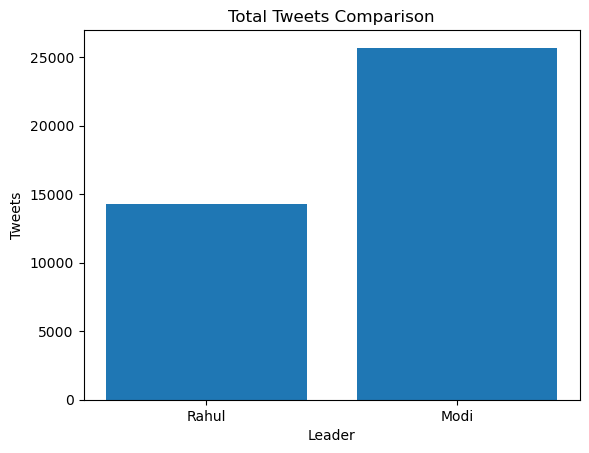

In [ ]:
data = {
    "Rahul": len(rahul),
    "Modi": len(modi)
}

plt.bar(data.keys(), data.values())

plt.title("Total Tweets Comparison")
plt.xlabel("Leader")
plt.ylabel("Tweets")

plt.show()

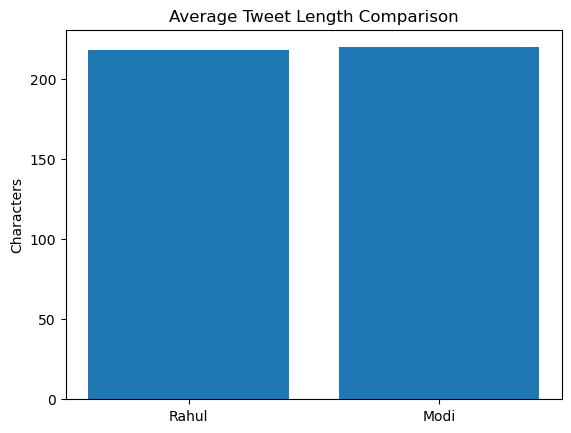

In [ ]:
avg_lengths = {
    "Rahul": rahul['tweet_length'].mean(),
    "Modi": modi['tweet_length'].mean()
}

plt.bar(avg_lengths.keys(),
        avg_lengths.values())

plt.title("Average Tweet Length Comparison")
plt.ylabel("Characters")
plt.show()

In [ ]:
rahul.to_csv(
    "cleaned_rahul_reviews.csv",
    index=False
)

modi.to_csv(
    "cleaned_modi_reviews.csv",
    index=False
)